# Ex 4 - Previsione del tasso di abbandono

Michael Wood | 2026-9-24

<img src="https://github.com/woodjmichael/Basi-Fondamentali-del-Machine-Learning/blob/main/images/churn_leaky_bucket.png?raw=true" height="500">

_Tasso di abbandono: misura di quanti clienti se ne vanno in un certo periodo — di solito un mese_

Questo notebook misura il churn mensile (abbandono dei clienti) su un campione di 1.000 clienti (POD), suddivisi in cinque cluster comportamentali, e prevede il churn di agosto con un modello di Poisson gerarchico bayesiano addestrato sui dati di gennaio–luglio.

**Risultati principali**

| Argomento | Analisi |
|---|---|
| Churn aprile–luglio (tutti i clienti) | Stabile all'**1,5–1,9% al mese**, 14–18 clienti |
| Churn gennaio–marzo | **Zero**: nessuno ha lasciato nei primi tre mesi |
| I cluster hanno churn diversi? | **Non in modo rilevabile** (p ≈ 0,18): le differenze osservate rientrano nel caso |
| Previsione per agosto | **18 abbandoni (1,9%)**, intervallo al 95%: 7–34 |
| Agosto effettivo | **38 abbandoni (4,1%)**, oltre l'intervallo previsto |

**Le curiosità**

- L'impennata di agosto è un'ondata di cambi di fornitore concentrata in un solo mese: 34 dei 38 clienti hanno lasciato il **1° agosto**.

- Nulla nel churn di gennaio–luglio lo lasciava prevedere, quindi l'errore del modello è esso stesso un risultato.

- Per prevedere salti di questo tipo servono informazioni esterne allo storico del churn (vedi le conclusioni).

**Indice**
1. **I dati**: importazione e organizzazione 
2. **Esplorazione:** attività, ingressi e uscite
3. Definizione e calcolo del **churn**
4. I **cluster** hanno churn diversi?
5. Scelta del **modello** di previsione
6. **Il modello:** Poisson gerarchico bayesiano
7. **Backtest:** quale modello prevede meglio?
8. **Previsione** di agosto
9. Conclusioni

## 1. I dati: importazione e organizzazione

Il file `daily_active_customers.xlsx` contiene due fogli:

- **`data`**: una riga per giorno (1 gen – 31 ago 2026) e una colonna per cliente. `1` = attivo quel giorno, `0` = non cliente quel giorno. Le prime 7 righe sono commenti, quindi l'intestazione vera è alla riga 8.
- **`clusters`**: per ogni POD, il cluster (1–5) e una descrizione ("persona") del profilo di consumo.

Un dettaglio preso dalle note del foglio conta per tutto il resto dell'analisi. Un `1` indica che il cliente è *considerato* attivo tra la prima e l'ultima lettura del contatore, e i buchi all'interno di quell'intervallo restano `1`. Ogni cliente è quindi registrato come un unico periodo continuo: entra una volta ed esce al massimo una volta. Si tratta di un'approssimazione del churn basata sui dati di carico, non di un'etichetta contrattuale.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2
from IPython.display import display

pd.set_option('display.width', 140)
CSV_DATA = 'https://raw.githubusercontent.com/woodjmichael/Basi-Fondamentali-del-Machine-Learning/refs/heads/main/data/daily_active_customers-data.csv'
CSV_CLUSTERS = 'https://raw.githubusercontent.com/woodjmichael/Basi-Fondamentali-del-Machine-Learning/refs/heads/main/data/daily_active_customers-clusters.csv'
MESI = ['Gen', 'Feb', 'Mar', 'Apr', 'Mag', 'Giu', 'Lug', 'Ago', 'Set', 'Ott', 'Nov', 'Dic']

# --- File 'data': date sulle righe, POD sulle colonne (intestazione alla riga 8) ---
data = pd.read_csv(CSV_DATA, header=7).rename(columns={'datetime': 'date'})
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date').sort_index()

# --- File 'clusters': pod -> numero di cluster + descrizione (intestazione alla riga 3) ---
clusters = pd.read_csv(CSV_CLUSTERS, header=2)
clusters = clusters[['pod', 'cluster', 'persona']].dropna(subset=['pod'])
clusters['cluster'] = clusters['cluster'].astype(int)
pod_to_cluster = clusters.set_index('pod')['cluster']
cluster_ids = sorted(clusters['cluster'].unique())

fmt = lambda d: f'{d.day} {MESI[d.month - 1].lower()} {d.year}'
print(f'{data.shape[1]} clienti x {data.shape[0]} giorni (dal {fmt(data.index.min())} al {fmt(data.index.max())})')

In [ ]:
# Dimensione e descrizione dei cluster
cluster_info = (clusters.groupby('cluster')
                .agg(clienti=('pod', 'size'), persona=('persona', 'first'))
                .assign(quota_pct=lambda d: (100 * d['clienti'] / d['clienti'].sum()).round(1)))
display(cluster_info[['clienti', 'persona']])

**Da sapere subito:** i cluster hanno dimensioni molto diverse. Il cluster 1 contiene l'85% dei clienti, il cluster 4 appena 6. Un solo abbandono nel cluster 4 sposta il suo tasso di churn di circa 17 punti, quindi i suoi tassi mensili sono in gran parte rumore. Il modello della sezione 6 è costruito proprio attorno a questo problema.

## 2. Esplorazione: attività, ingressi e uscite

Prima alcune impostazioni grafiche comuni, così tutti i grafici hanno lo stesso aspetto: linee sottili, griglia leggera e testo neutro. Ogni cluster mantiene lo stesso colore in tutti i grafici.

In [22]:
# Stile comune dei grafici
SURFACE, INK, INK_2, GRID = '#fcfcfb', '#0b0b0b', '#52514e', '#e4e3df'
CLUSTER_COLORS = {1: '#2a78d6', 2: '#eb6834', 3: '#1baf7a', 4: '#eda100', 5: '#e87ba4'}
ALL_COLOR = INK_2        # colore neutro per la serie 'tutti i clienti'
ACCENT = '#eb6834'       # previsione / evidenziazione

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK_2, 'axes.titlecolor': INK,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'xtick.color': INK_2, 'ytick.color': INK_2, 'text.color': INK,
    'lines.linewidth': 2, 'font.size': 10, 'legend.frameon': False,
    'figure.dpi': 110,
})
fmt_mese = FuncFormatter(lambda x, pos: MESI[mdates.num2date(x).month - 1])  # etichette dei mesi in italiano

periods = data.index.to_period('M')
months = sorted(periods.unique())                   # gen..ago
month_names = [MESI[m.month - 1] for m in months]
leave_events = (data.shift(1) == 1) & (data == 0)   # attivo ieri, inattivo oggi = uscita
join_events = (data.shift(1) == 0) & (data == 1)    # inattivo ieri, attivo oggi = ingresso

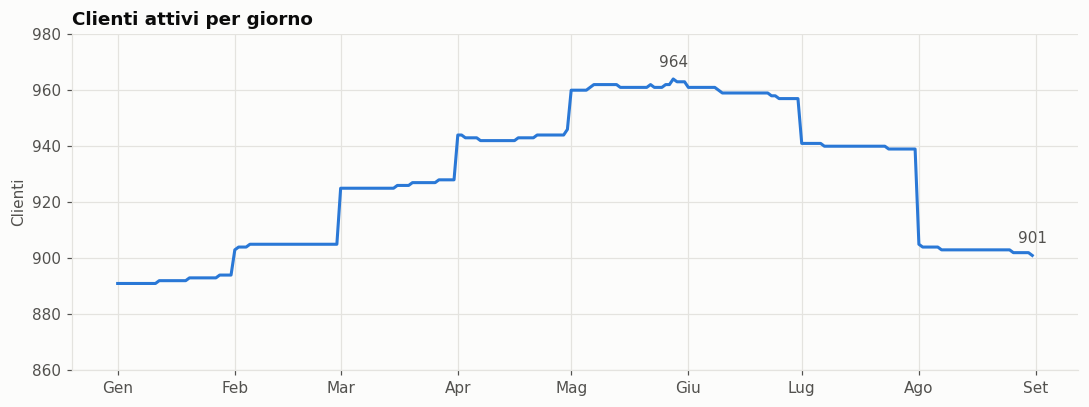

In [23]:
# Figura 1: clienti attivi ogni giorno
active = data.sum(axis=1)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(active.index, active.values, color=CLUSTER_COLORS[1])
for d in [active.idxmax(), active.index[-1]]:
    ax.annotate(f'{active[d]:,}', (d, active[d]), textcoords='offset points', xytext=(0, 8),
                ha='center', color=INK_2)
ax.set_title('Clienti attivi per giorno')
ax.set_ylabel('Clienti')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(fmt_mese)
ax.set_ylim(860, 980)
plt.tight_layout(); plt.show()

La base clienti cresce da 891 a un picco di 964 a fine maggio, poi scende a 901 a fine agosto. I gradini sono netti e cadono a cavallo dei mesi: i due grafici seguenti spiegano perché.

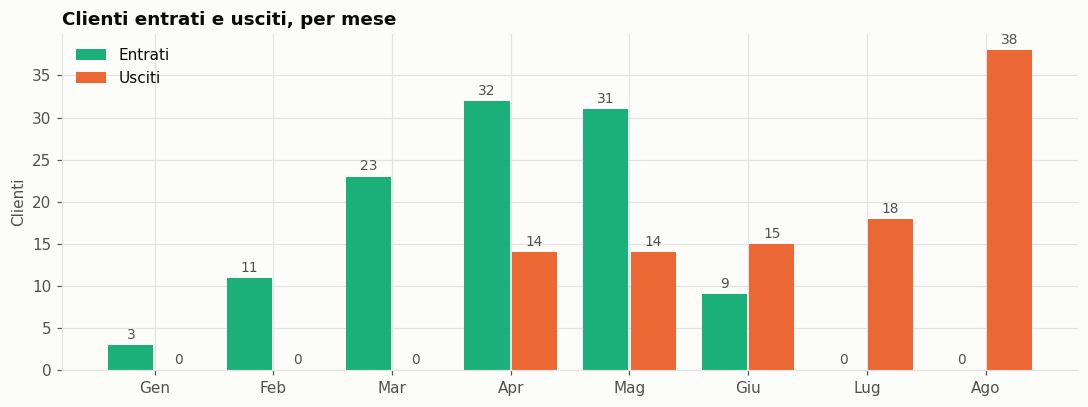

In [24]:
# Figura 2: clienti entrati e usciti per mese
joins_m = join_events.groupby(periods).sum().sum(axis=1)
leaves_m = leave_events.groupby(periods).sum().sum(axis=1)

x = np.arange(len(months)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 3.8))
b1 = ax.bar(x - w/2 - 0.01, joins_m.values, w, color=CLUSTER_COLORS[3], label='Entrati')
b2 = ax.bar(x + w/2 + 0.01, leaves_m.values, w, color=CLUSTER_COLORS[2], label='Usciti')
for bars in (b1, b2):
    ax.bar_label(bars, padding=2, color=INK_2, fontsize=9)
ax.set_xticks(x, month_names)
ax.set_title('Clienti entrati e usciti, per mese')
ax.set_ylabel('Clienti')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

**Curiosità in questo grafico:**

- **Nessun abbandono tra gennaio e marzo.** Il churn inizia solo ad aprile, resta a 14–18 al mese e poi sale a 38 ad agosto.
- **Dopo giugno non entrano più nuovi clienti.** Gli ingressi toccano il massimo ad aprile–maggio (31–32 al mese), scendono a 9 a giugno e sono zero a luglio e agosto. La crescita si trasforma in calo proprio quando l'acquisizione si ferma *e* il churn aumenta.
- **Ogni cliente entra al massimo una volta ed esce al massimo una volta.** È una conseguenza di come sono stati costruiti i dati (vedi sezione 1): nessun cliente esce e poi ritorna.

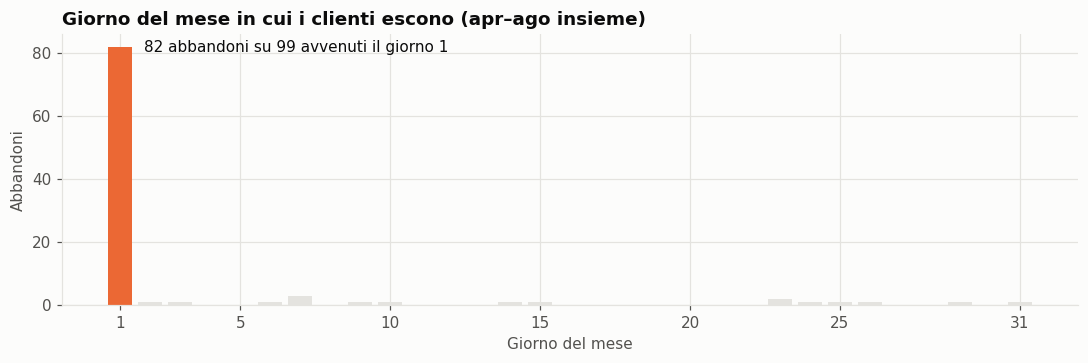

Ingressi avvenuti il giorno 1 del mese: 89 su 109


In [25]:
# Figura 3: in quale giorno del mese escono i clienti?
leave_by_dom = leave_events.sum(axis=1)
leave_by_dom = leave_by_dom[leave_by_dom > 0].groupby(leave_by_dom[leave_by_dom > 0].index.day).sum()
leave_by_dom = leave_by_dom.reindex(range(1, 32), fill_value=0)
join_by_dom = join_events.sum(axis=1)
join_by_dom = join_by_dom[join_by_dom > 0].groupby(join_by_dom[join_by_dom > 0].index.day).sum()

fig, ax = plt.subplots(figsize=(10, 3.4))
colors = [CLUSTER_COLORS[2] if d == 1 else GRID for d in leave_by_dom.index]
ax.bar(leave_by_dom.index, leave_by_dom.values, color=colors, width=0.8)
ax.text(1.8, leave_by_dom[1], f'{leave_by_dom[1]} abbandoni su {leave_by_dom.sum()} avvenuti il giorno 1',
        va='center', color=INK)
ax.set_title('Giorno del mese in cui i clienti escono (apr–ago insieme)')
ax.set_xlabel('Giorno del mese'); ax.set_ylabel('Abbandoni')
ax.set_xticks([1, 5, 10, 15, 20, 25, 31])
plt.tight_layout(); plt.show()

print(f'Ingressi avvenuti il giorno 1 del mese: {join_by_dom.get(1, 0)} su {int(join_by_dom.sum())}')

**Curiosità: il churn avviene il giorno 1.** 82 abbandoni su 99, e 89 ingressi su 109, cadono il primo giorno del mese. È coerente con i cambi di fornitore, che di norma decorrono dall'inizio del mese. "Churn nel mese M" significa quindi, in pratica, "cambi di fornitore decorrenti dal 1° di M", richiesti nel mese precedente. Questa tempistica è la chiave per leggere l'impennata di agosto.

In [27]:
# Chi esce: clienti attivi dal 1° gennaio o clienti entrati durante il periodo?
first_day = data.idxmax().where(data.max() == 1)
left_day = leave_events.idxmax().where(leave_events.any())
who = pd.DataFrame({'first_day': first_day, 'left_day': left_day})
who['original'] = who['first_day'] == data.index[0]
leavers = who.dropna(subset=['left_day'])

orig_total, new_total = int(who['original'].sum()), int((~who['original'] & who['first_day'].notna()).sum())
print(f"Clienti originari (attivi il 1° gen): usciti {int(leavers['original'].sum())} su {orig_total} "
      f"({100 * leavers['original'].sum() / orig_total:.1f}%)")
print(f"Clienti entrati durante il periodo: usciti {int((~leavers['original']).sum())} su {new_total} "
      f"({100 * (~leavers['original']).sum() / new_total:.1f}%)")

Clienti originari (attivi il 1° gen): usciti 93 su 891 (10.4%)
Clienti entrati durante il periodo: usciti 6 su 109 (5.5%)


**Curiosità: quasi tutti quelli che escono sono clienti di lunga data.** 93 abbandoni su 99 riguardano clienti già attivi il 1° gennaio. I clienti entrati di recente *non* escono più spesso, quindi non c'è un effetto "clienti in prova che se ne vanno". Il churn cresce con il calendario, non con l'anzianità del cliente, e questo esclude i modelli di retention basati sull'anzianità (sezione 5).

## 3. Definizione e calcolo del churn

Per ogni mese *M*:

- **Coorte di partenza:** clienti attivi l'**ultimo giorno del mese M−1**. Per gennaio, i clienti attivi il **1° gennaio**.
- **Abbandoni:** clienti della coorte che risultano inattivi in **un giorno qualsiasi del mese M**.
- **Tasso di churn** = abbandoni ÷ coorte di partenza.
- **Churn assoluto** = numero di clienti che escono in un giorno qualsiasi di M.

I clienti che entrano durante il mese M non fanno parte della coorte di quel mese, quindi non contano nel suo tasso di churn. In questi dati nessuno entra ed esce nello stesso mese, per cui il churn assoluto coincide ogni mese con il numero di abbandoni. Le due misure sono comunque calcolate separatamente, nel caso in cui questo cambi.

In [28]:
def churn_panel(pods_by_cluster):
    # Una riga per (cluster, mese): coorte, abbandoni, churn assoluto, tasso di churn
    rows = []
    for cid, pods in pods_by_cluster.items():
        sub = data[pods]
        for t, month in enumerate(months, start=1):
            month_days = sub[periods == month]
            if t == 1:                                            # gennaio: riferimento = 1° gen
                base = month_days.index.min()
                check = month_days.loc[month_days.index > base]
            else:                                                 # altri mesi: ultimo giorno di M-1
                base = sub[periods == months[t - 2]].index.max()
                check = month_days
            cohort = sub.loc[base] == 1
            left = (check.loc[:, cohort] == 0).any(axis=0)        # inattivo in un giorno qualsiasi di M
            rows.append({
                'cluster': cid, 't': t, 'mese': MESI[month.month - 1],
                'coorte': int(cohort.sum()),
                'abbandoni': int(left.sum()),
                'churn_assoluto': int(leave_events.loc[periods == month, pods].any(axis=0).sum()),
            })
    out = pd.DataFrame(rows)
    out['tasso_churn_pct'] = (100 * out['abbandoni'] / out['coorte']).round(2)
    return out

pods_by_cluster = {c: [p for p in pod_to_cluster[pod_to_cluster == c].index if p in data.columns]
                   for c in cluster_ids}
panel = churn_panel(pods_by_cluster)
panel_all = churn_panel({'Tutti': list(data.columns)})

print('Tasso di churn (%) per cluster:')
rate_tbl = panel.pivot(index='t', columns='cluster', values='tasso_churn_pct')
rate_tbl['Tutti'] = panel_all.set_index('t')['tasso_churn_pct']
rate_tbl.index = month_names
display(rate_tbl)

print('Churn assoluto (clienti usciti) per cluster:')
abs_tbl = panel.pivot(index='t', columns='cluster', values='churn_assoluto')
abs_tbl['Tutti'] = panel_all.set_index('t')['churn_assoluto']
abs_tbl.index = month_names
display(abs_tbl)

Tasso di churn (%) per cluster:


cluster,1,2,3,4,5,Tutti
Gen,NaN,NaN,NaN,NaN,NaN,0.00
Feb,NaN,NaN,NaN,NaN,NaN,0.00
Mar,NaN,NaN,NaN,NaN,NaN,0.00
Apr,NaN,NaN,NaN,NaN,NaN,1.51
Mag,NaN,NaN,NaN,NaN,NaN,1.48
Giu,NaN,NaN,NaN,NaN,NaN,1.56
Lug,NaN,NaN,NaN,NaN,NaN,1.88
Ago,NaN,NaN,NaN,NaN,NaN,4.05


Churn assoluto (clienti usciti) per cluster:


cluster,1,2,3,4,5,Tutti
Gen,0,0,0,0,0,0
Feb,0,0,0,0,0,0
Mar,0,0,0,0,0,0
Apr,0,0,0,0,0,14
Mag,0,0,0,0,0,14
Giu,0,0,0,0,0,15
Lug,0,0,0,0,0,18
Ago,0,0,0,0,0,38


In [ ]:
# Figura 4: tasso di churn per cluster, un piccolo pannello per cluster (asse y condiviso)
fig, axes = plt.subplots(1, 6, figsize=(12, 3.2), sharey=True)
series = [(c, panel[panel['cluster'] == c], CLUSTER_COLORS[c], f'Cluster {c}') for c in cluster_ids]
series.append(('Tutti', panel_all, ALL_COLOR, 'Tutti i clienti'))
for ax, (cid, df, color, title) in zip(axes, series):
    ax.plot(df['t'], df['tasso_churn_pct'], color=color, marker='o', markersize=4)
    ax.set_title(f'{title}\n(~{int(df["coorte"].median())} a rischio)', fontsize=10)
    ax.set_xticks(range(1, 9), ['G', 'F', 'M', 'A', 'M', 'G', 'L', 'A'])
axes[0].set_ylabel('Tasso di churn (%)')
fig.suptitle('Tasso di churn mensile per cluster', x=0.01, ha='left', fontweight='bold', color=INK)
plt.tight_layout(); plt.show()

Il cluster 1 (85% dei clienti) si comporta esattamente come il portafoglio nel suo insieme: fermo a zero fino a marzo, circa 1,5% da aprile e un salto ad agosto. I cluster piccoli oscillano molto. Il cluster 4 arriva al 17–20% a luglio e agosto, ma si tratta di 1 cliente su 6 e poi di 1 su 5.

## 4. I cluster hanno churn diversi?

I cluster 2 e 4 *sembrano* avere più churn. Prima di inserire questa differenza in una previsione, conviene verificare se è più grande di quanto produrrebbe il caso. Confronto due spiegazioni del churn di aprile–luglio (i mesi in cui c'è churn):

- **Stesso tasso:** tutti i cluster hanno il tasso di churn del portafoglio.
- **Tasso proprio:** ogni cluster ha il suo tasso di churn.

Un test del rapporto di verosimiglianza verifica se tassi separati spiegano i dati in modo significativamente migliore. Poiché i conteggi sono piccoli, calcolo il p-value anche per simulazione, invece di affidarmi solo all'approssimazione chi-quadro.

In [ ]:
q = panel[panel['t'].between(4, 7)].groupby('cluster')[['abbandoni', 'coorte']].sum()
q['tasso_churn_pct'] = (100 * q['abbandoni'] / q['coorte']).round(2)
display(q)

def binom_ll(y, n, r):
    r = np.clip(r, 1e-12, 1 - 1e-12)
    return np.sum(y * np.log(r) + (n - y) * np.log(1 - r))

y, n = q['abbandoni'].values, q['coorte'].values
pooled = y.sum() / n.sum()
lr = 2 * (binom_ll(y, n, y / n) - binom_ll(y, n, pooled))
p_asym = 1 - chi2.cdf(lr, df=len(q) - 1)

rng = np.random.default_rng(0)                   # simula 20.000 volte il mondo 'stesso tasso'
sim = rng.binomial(n, pooled, size=(20000, len(n)))
lr_sim = np.array([2 * (binom_ll(s, n, s / n) - binom_ll(s, n, s.sum() / n.sum())) for s in sim])
p_sim = np.mean(lr_sim >= lr)
print(f'Statistica del rapporto di verosimiglianza {lr:.2f}: p = {p_asym:.3f} (chi-quadro), p = {p_sim:.3f} (simulazione)')

**Curiosità: i cluster comportamentali non mostrano churn chiaramente diversi.** Con p ≈ 0,18–0,19, le differenze tra cluster rientrano ampiamente in ciò che la variabilità casuale produce con campioni di queste dimensioni. Il cluster 2 (4,6% in aprile–luglio) è il caso più suggestivo, ma si tratta di 6 abbandoni. I cluster descrivono *come* i clienti consumano elettricità, e questo non dice necessariamente *se* se ne andranno.

Il test non dimostra che i cluster siano identici, solo che i dati non riescono ancora a distinguerli. Il modello di previsione deve quindi permettere differenze tra cluster, ma avvicinarli al tasso comune a meno di prove forti. È esattamente ciò che fa un modello gerarchico.

## 5. Scelta del modello di previsione

La retta di tendenza usata in precedenza ha tre problemi: tratta un cluster di 6 clienti come uno di 846, può prevedere un churn negativo e non fornisce alcun intervallo di incertezza. Ho valutato le alternative standard:

| Approccio | Adatto a questi dati? |
|---|---|
| **Regressione di Poisson con offset di esposizione** | ✔ Il modello standard per "quanti eventi su *n* a rischio". Il tasso è modellato per cliente a rischio e scalato per la coorte del mese ([The Analysis Factor](https://www.theanalysisfactor.com/the-exposure-variable-in-poission-regression-models/)). |
| **Effetti di cluster gerarchici (partial pooling)** | ✔ I gruppi piccoli "prendono in prestito" informazione dall'insieme: il livello di ogni cluster è avvicinato al tasso comune, e i cluster piccoli lo sono di più ([vignetta rstanarm](https://cran.r-project.org/web/packages/rstanarm/vignettes/pooling.html)). Coerente con il risultato della sezione 4. |
| **Modello di retention shifted-beta-geometric** ([Fader & Hardie](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=801145)) | ✘ Il modello classico per la retention degli abbonamenti, ma presuppone che il churn *diminuisca* con l'anzianità del cliente. Qui il churn *aumenta* con il calendario, ed escono proprio i clienti di lunga data (sezione 2). |
| **Classificatori per singolo cliente** (regressione logistica ecc.) | ✘ I flag giornalieri 0/1 non danno quasi nessun segnale prima dell'uscita: i clienti sono pienamente attivi fino al giorno del cambio. |

**Scelta: un modello di Poisson gerarchico bayesiano.** È stimato con MCMC in numpy puro (statsmodels e PyMC non erano disponibili), quindi il notebook richiede solo numpy, pandas, scipy e matplotlib.

## 6. Il modello: Poisson gerarchico bayesiano

Per il cluster *c* nel mese *t*:

$$\text{abbandoni}_{c,t} \sim \text{Poisson}\big(\text{coorte}_{c,t} \cdot e^{\,\alpha + \beta t + u_c}\big), \qquad u_c = \sigma z_c,\; z_c \sim \mathcal N(0,1)$$

| Componente | Significato |
|---|---|
| `coorte ×` | esposizione: il modello prevede un tasso per cliente a rischio, poi lo moltiplica per il numero di clienti a rischio |
| $\alpha$ | tasso di base complessivo (in scala logaritmica) |
| $\beta$ | tendenza mensile comune; $e^{\beta}$ è il moltiplicatore da un mese al successivo, ad es. 1,07 = +7% |
| $u_c$ | correzione del cluster, estratta da una distribuzione comune con dispersione $\sigma$ |
| prior | $\alpha \sim N(-4, 2^2)$ (circa 2% al mese, molto vago), $\beta \sim N(0; 0{,}5^2)$ (nessuna tendenza a priori), $\sigma \sim \text{HalfNormal}(0{,}5)$ (differenze tra cluster moderate, mai forzate a zero) |

**Stima:** MCMC con Metropolis adattivo. Il campionatore compie decine di migliaia di piccoli passi casuali nello spazio dei parametri e li conserva in proporzione a quanto bene spiegano i dati, così i campioni conservati descrivono sia le stime migliori sia la loro incertezza. L'ampiezza dei passi viene tarata durante una fase iniziale di riscaldamento ("burn-in"), che poi viene scartata.

**Previsione:** per ogni campione conservato si calcola il tasso di agosto e si estrae un numero casuale di abbandoni. La dispersione di questi conteggi simulati fornisce gli intervalli di previsione, che includono sia l'incertezza sul tasso sia la normale variabilità da un mese all'altro.

Due opzioni generano le varianti confrontate nella sezione 7: `trend` (sì/no) e `start_t` (stima da gennaio, oppure da aprile, quando è iniziato il churn).

In [ ]:
SEED = 42

class BayesHierPoisson:
    # Modello di Poisson per tassi: intercetta comune + tendenza opzionale + effetto di cluster parzialmente aggregato
    def __init__(self, trend=True, start_t=1, name=None, seed=SEED):
        self.trend, self.start_t, self.seed = trend, start_t, seed
        self.name = name or f"Poisson gerarchico ({'trend' if trend else 'piatto'}, dal mese {start_t})"

    def _logpost(self, p):
        # log-posterior = log-verosimiglianza di Poisson + log-prior
        a, b, log_s, z = p[0], p[1], p[2], p[3:]
        s = np.exp(log_s)
        eta = a + (b * self.t if self.trend else 0.0) + s * z[self.ci]  # log del tasso di churn per riga
        ll = np.sum(self.y * eta - self.n * np.exp(eta))                 # nucleo di Poisson con esposizione
        lp = (-0.5 * ((a + 4) / 2) ** 2                                  # alpha ~ N(-4, 2^2)
              - 0.5 * (b / 0.5) ** 2                                     # beta  ~ N(0, 0.5^2)
              - 0.5 * (s / 0.5) ** 2 + log_s                             # sigma ~ HalfNormal(0.5) (+ jacobiano)
              - 0.5 * np.sum(z ** 2))                                    # z_c   ~ N(0, 1)
        return ll + lp

    def fit(self, df, iters=40000, burn=10000, thin=10):
        df = df[df['t'] >= self.start_t]
        self.cids = sorted(df['cluster'].unique())
        self.ci = df['cluster'].map({c: i for i, c in enumerate(self.cids)}).values
        self.t, self.y, self.n = df['t'].values.astype(float), df['abbandoni'].values, df['coorte'].values
        rng = np.random.default_rng(self.seed)
        k = 3 + len(self.cids)
        p = np.r_[np.log(max(self.y.sum(), 0.5) / self.n.sum()), 0.0, np.log(0.2), np.zeros(len(self.cids))]
        lp, cov, chain, hist = self._logpost(p), np.eye(k) * 0.01, [], []
        for i in range(iters):
            prop = p + rng.multivariate_normal(np.zeros(k), cov * 2.38 ** 2 / k)   # proponi un passo
            if not self.trend:
                prop[1] = 0.0
            lp_prop = self._logpost(prop)
            if np.log(rng.random()) < lp_prop - lp:                             # accetta/rifiuta (Metropolis)
                p, lp = prop, lp_prop
            hist.append(p.copy())
            if 2000 <= i < burn and i % 500 == 0:                                # taratura dei passi nel burn-in
                cov = np.cov(np.array(hist[-5000:]).T) + np.eye(k) * 1e-6
            if i >= burn and i % thin == 0:                                      # conserva un campione ogni 10
                chain.append(p.copy())
        self.chain = np.array(chain)
        return self

    def predictive(self, cid, t, n, rng):
        # Conteggi di abbandoni simulati (e i tassi da cui derivano) per il cluster cid, mese t, n a rischio
        a, b, s = self.chain[:, 0], self.chain[:, 1], np.exp(self.chain[:, 2])
        z = self.chain[:, 3 + self.cids.index(cid)]
        rate = np.exp(a + (b * t if self.trend else 0.0) + s * z)
        return rng.poisson(n * rate), rate

    def predict_mean(self, cid, t, n):
        return n * self.predictive(cid, t, n, np.random.default_rng(self.seed))[1].mean()

# Modelli di riferimento semplici che il modello deve battere
class LastMonthRate:
    name = 'Riferimento: tasso del cluster nel mese precedente'
    def fit(self, df): self.df = df; return self
    def predict_mean(self, cid, t, n):
        r = self.df[(self.df['cluster'] == cid) & (self.df['t'] == t - 1)].iloc[0]
        return n * r['abbandoni'] / r['coorte']

class PooledRecentRate:
    name = 'Riferimento: tasso del portafoglio, ultimi 3 mesi'
    def fit(self, df): self.df = df; return self
    def predict_mean(self, cid, t, n):
        g = self.df[self.df['t'].between(t - 3, t - 1)]
        return n * g['abbandoni'].sum() / g['coorte'].sum()

def poisson_deviance(y, mu):
    # Più basso = meglio. Valuta le previsioni di conteggi in modo equo:
    # prevedere 3 quando il valore reale è 0 pesa più che prevedere 18 quando è 15
    y, mu = np.asarray(y, float), np.maximum(np.asarray(mu, float), 1e-9)
    term = np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0.0)
    return float(2 * np.sum(term - (y - mu)))

## 7. Backtest: quale modello prevede meglio?

Per scegliere un modello senza guardare agosto, ogni candidato prevede un mese che non ha visto, usando solo i dati precedenti:

- addestramento su **gennaio–maggio**, previsione di **giugno**
- addestramento su **gennaio–giugno**, previsione di **luglio**

I cinque candidati sono due modelli di riferimento semplici e tre versioni del modello gerarchico. La versione stimata da aprile verifica se gli zeri di gennaio–marzo vadano esclusi dalla stima della tendenza.

In [ ]:
def make_candidates():
    return [
        LastMonthRate(),
        PooledRecentRate(),
        BayesHierPoisson(trend=True,  start_t=1, name='Poisson gerarchico, trend, stima da gen'),
        BayesHierPoisson(trend=True,  start_t=4, name='Poisson gerarchico, trend, stima da apr'),
        BayesHierPoisson(trend=False, start_t=4, name='Poisson gerarchico, piatto, stima da apr'),
    ]

bt = []
for target in (6, 7):
    train, test = panel[panel['t'] < target], panel[panel['t'] == target]
    for m in make_candidates():
        m.fit(train)
        preds = np.array([m.predict_mean(r.cluster, target, r.coorte) for r in test.itertuples()])
        bt.append({'modello': m.name, 'mese': month_names[target - 1],
                   'prev_totale': preds.sum(), 'eff_totale': test['abbandoni'].sum(),
                   'err_ass': np.abs(preds - test['abbandoni'].values).sum(),
                   'devianza': poisson_deviance(test['abbandoni'], preds)})
bt = pd.DataFrame(bt)

backtest = bt.groupby('modello', sort=False).agg(
    previsti_giu=('prev_totale', 'first'), previsti_lug=('prev_totale', 'last'),
    errore_per_cluster=('err_ass', lambda s: s.sum() / (2 * len(cluster_ids))),
    devianza=('devianza', 'sum')).round(2)
print(f"Abbandoni effettivi: giugno {int(bt['eff_totale'].iloc[0])}, luglio {int(bt['eff_totale'].iloc[-1])}")
display(backtest)
best_name = backtest['devianza'].idxmin()
print(f'Modello scelto (devianza minima): {best_name}')

In [ ]:
# Figura 5: errore di backtest per modello (più basso = meglio)
order = backtest.sort_values('devianza', ascending=False)
fig, ax = plt.subplots(figsize=(10, 3.4))
colors = [CLUSTER_COLORS[1] if name == best_name else GRID for name in order.index]
bars = ax.barh(order.index, order['devianza'], color=colors, height=0.6)
ax.bar_label(bars, fmt='%.1f', padding=3, color=INK_2)
ax.set_title('Errore di backtest per modello (più basso = meglio)')
ax.set_xlabel('Devianza di Poisson totale, giugno + luglio'); ax.grid(axis='y', visible=False)
ax.set_xlim(0, order['devianza'].max() * 1.12)
plt.tight_layout(); plt.show()

**Cosa emerge dal backtest:**

- **Gli zeri di gennaio–marzo rovinano una tendenza stimata da gennaio.** Tre mesi a zero seguiti da circa l'1,5% fanno salire la tendenza in modo troppo ripido: il modello prevede circa 35 abbandoni sia per giugno sia per luglio (effettivi: 15 e 18).
- **La stima da aprile vince**, con la devianza più bassa e un errore di circa 0,75 abbandoni per cluster. Il churn si comporta come qualcosa che si è *acceso* ad aprile, non come una curva regolare che parte da gennaio.
- **"Ripetere il mese precedente" azzecca più o meno i totali ma sbaglia molto sui cluster piccoli.** Quando un cluster piccolo ha per caso 0 abbandoni, prevede 0 anche per il mese dopo, e la devianza penalizza molto questo errore.

## 8. Previsione di agosto

Il modello scelto viene ristimato su tutti i dati fino a luglio. Poiché la stima parte da aprile, si tratta di aprile–luglio, con un'esecuzione più lunga per maggiore precisione. Poi il modello prevede agosto. La coorte di agosto (clienti attivi il 31 luglio) è nota alla fine di luglio, quindi usarla non introduce informazioni dal futuro.

Prima, una verifica che l'MCMC sia arrivato a convergenza. Tre esecuzioni indipendenti devono concordare, cioè avere un R-hat vicino a 1,00.

In [ ]:
final_train = panel[panel['t'] <= 7]
runs = [BayesHierPoisson(trend=True, start_t=4, seed=s).fit(final_train, iters=80000, burn=20000)
        for s in (42, 7, 2026)]
C = np.array([r.chain for r in runs])                 # (esecuzioni, campioni, parametri)
W = C.var(axis=1, ddof=1).mean(axis=0)
B = C.shape[1] * C.mean(axis=1).var(axis=0, ddof=1)
rhat = np.sqrt(((C.shape[1] - 1) / C.shape[1] * W + B / C.shape[1]) / W)
print('R-hat (alpha, beta, log sigma, z1..z5):', np.round(rhat, 3))

model = runs[0]
ch = model.chain
beta, sigma = ch[:, 1], np.exp(ch[:, 2])
print(f'Tendenza: x{np.exp(beta.mean()):.2f} al mese '
      f'(intervallo al 90%: da x{np.exp(np.percentile(beta, 5)):.2f} a x{np.exp(np.percentile(beta, 95)):.2f})')
print(f'Dispersione tra cluster sigma: {sigma.mean():.2f}')

L'R-hat è 1,00 per tutti i parametri, quindi le esecuzioni concordano. La tendenza è lieve (circa +7% al mese) e il suo intervallo include "nessuna tendenza". Prima di agosto, il churn era di fatto stabile intorno all'1,5–1,9%.

In [ ]:
rng = np.random.default_rng(SEED)
aug = panel[panel['t'] == 8].set_index('cluster')
rows, total_draws, count_draws = [], 0, {}
for cid in cluster_ids:
    n = int(aug.loc[cid, 'coorte'])
    draws, rate = model.predictive(cid, 8, n, rng)
    total_draws = total_draws + draws
    count_draws[cid] = draws
    rows.append({'cluster': cid, 'a_rischio_31lug': n,
                 'previsti': round(draws.mean(), 1),
                 'intervallo_80%': f'{int(np.percentile(draws, 10))}–{int(np.percentile(draws, 90))}',
                 'intervallo_95%': f'{int(np.percentile(draws, 2.5))}–{int(np.percentile(draws, 97.5))}',
                 'tasso_previsto_pct': round(100 * rate.mean(), 2),
                 'effettivi': int(aug.loc[cid, 'abbandoni']),
                 'tasso_effettivo_pct': round(aug.loc[cid, 'tasso_churn_pct'], 2)})
n_all = int(aug['coorte'].sum())
rows.append({'cluster': 'Tutti', 'a_rischio_31lug': n_all,
             'previsti': round(total_draws.mean(), 1),
             'intervallo_80%': f'{int(np.percentile(total_draws, 10))}–{int(np.percentile(total_draws, 90))}',
             'intervallo_95%': f'{int(np.percentile(total_draws, 2.5))}–{int(np.percentile(total_draws, 97.5))}',
             'tasso_previsto_pct': round(100 * total_draws.mean() / n_all, 2),
             'effettivi': int(aug['abbandoni'].sum()),
             'tasso_effettivo_pct': round(100 * aug['abbandoni'].sum() / n_all, 2)})
forecast = pd.DataFrame(rows).set_index('cluster')
display(forecast)
print(f"Probabilità di 38 o più abbandoni secondo il modello: {np.mean(total_draws >= 38):.2%}")

In [ ]:
# Figura 6: abbandoni mensili, gen-lug effettivi, agosto previsto vs effettivo
monthly = panel_all.set_index('t')['abbandoni']
lo95, hi95 = np.percentile(total_draws, [2.5, 97.5])
lo80, hi80 = np.percentile(total_draws, [10, 90])

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 8), monthly.loc[1:7], color=CLUSTER_COLORS[1], width=0.6, label='Effettivi')
ax.bar(8.17, monthly.loc[8], color=CLUSTER_COLORS[1], width=0.3)
ax.vlines(7.83, lo95, hi95, color=ACCENT, lw=2, label='Previsione: intervallo 95%')
ax.vlines(7.83, lo80, hi80, color=ACCENT, lw=7, alpha=0.55, label='Previsione: intervallo 80%')
ax.plot(7.83, total_draws.mean(), 'o', color=ACCENT, ms=8, mec=SURFACE, mew=2, label='Previsione: media')
for t in range(1, 8):
    ax.text(t, monthly[t] + 0.6, str(monthly[t]), ha='center', color=INK_2, fontsize=9)
ax.text(8.17, monthly[8] + 0.6, f'{monthly[8]}\neffettivi', ha='center', va='bottom', color=INK, fontsize=9)
ax.text(7.62, total_draws.mean(), f'{total_draws.mean():.0f}', ha='right', va='center', color=INK, fontsize=9)
ax.axvspan(7.5, 8.5, color=GRID, alpha=0.35, lw=0, zorder=0)
ax.set_xticks(range(1, 9), month_names)
ax.set_ylim(0, 46)
ax.set_title('Clienti usciti per mese: previsione di agosto vs effettivo')
ax.set_ylabel('Abbandoni'); ax.grid(axis='x', visible=False)
ax.legend(loc='upper left', ncol=2)
plt.tight_layout(); plt.show()

In [ ]:
# Figura 7: tasso di churn di agosto previsto vs effettivo, per cluster.
# L'intervallo riguarda il tasso OSSERVATO (abbandoni simulati / a rischio), quindi include la
# variabilità casuale da un mese all'altro, che domina nei cluster piccoli, ed è direttamente
# confrontabile con il valore effettivo.
fig, ax = plt.subplots(figsize=(10, 3.8))
labels = [f'Cluster {c}\n(n={int(aug.loc[c, "coorte"])})' for c in cluster_ids] + [f'Tutti\n(n={n_all})']
for i, cid in enumerate(cluster_ids + ['Tutti']):
    n_c = n_all if cid == 'Tutti' else int(aug.loc[cid, 'coorte'])
    r = 100 * (total_draws if cid == 'Tutti' else count_draws[cid]) / n_c
    lo, hi = np.percentile(r, [2.5, 97.5])
    color = ALL_COLOR if cid == 'Tutti' else CLUSTER_COLORS[cid]
    ax.vlines(i, lo, hi, color=color, lw=2)
    ax.plot(i, r.mean(), 'o', color=color, ms=8, mec=SURFACE, mew=2,
            label='Tasso previsto: media e intervallo 95%' if i == 0 else None)
    ax.plot(i + 0.18, forecast.loc[cid, 'tasso_effettivo_pct'], 'D', color=INK, ms=6,
            label='Tasso effettivo di agosto' if i == 0 else None)
ax.set_xticks(range(6), labels)
ax.set_ylabel('Tasso di churn (%)')
ax.set_title('Tasso di churn di agosto per cluster: previsto vs effettivo')
ax.grid(axis='x', visible=False)
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

**Come leggere i risultati:**

- **La previsione di circa 18 abbandoni era una lettura corretta di gennaio–luglio.** Da aprile a luglio il churn è rimasto a 14–18 al mese senza una vera tendenza, e tutti i modelli che descrivevano bene quel periodo prevedevano 15–19.
- **Agosto è arrivato a 38, fuori dall'intervallo al 95%.** Secondo il modello la probabilità di 38 o più abbandoni è inferiore all'1%, quindi non è sfortuna: qualcosa è cambiato.
- **Il cambiamento è concentrato il 1° agosto:** 34 dei 38 clienti sono usciti quel giorno, contro 9–16 il giorno 1 dei mesi precedenti. I clienti hanno cambiato fornitore in un'unica ondata, un evento esterno e non una tendenza graduale.
- **Gli intervalli di previsione dei cluster piccoli sono ampi, e deve essere così.** Il 20% del cluster 4 è 1 cliente su 5, il 7% del cluster 3 è 2 clienti su 28. Entrambi i valori effettivi cadono dentro i rispettivi intervalli al 95%: con così pochi clienti basta un solo abbandono per produrre un tasso del genere.
- **Il cluster 1 da solo spiega l'errore:** 33 abbandoni contro circa 15 previsti. L'ondata di cambi ha colpito la base clienti principale, non un cluster di nicchia.

## 9. Conclusioni

**Cosa mostrano i dati**
1. Il churn è iniziato ad aprile ed è rimasto stabile intorno all'**1,5–1,9% al mese** (14–18 clienti) fino a luglio, poi è **raddoppiato al 4,1% (38 clienti) ad agosto**.
2. **Il churn avviene il giorno 1 del mese**, così come gli ingressi, coerentemente con il calendario dei cambi di fornitore.
3. **Escono i clienti di lunga data** (93 su 99 erano clienti già il 1° gennaio), quindi il churn non è un problema dei nuovi clienti.
4. **L'acquisizione si è fermata dopo giugno** (nessun ingresso a luglio e agosto). Insieme all'aumento del churn, la base clienti è scesa da 964 a 901.
5. **I cluster basati sul profilo di consumo non prevedono in modo affidabile il churn** (p ≈ 0,18). Il cluster 1, con l'85% dei clienti, determina i totali.

**Cosa mostra il modello**
- Un modello di Poisson gerarchico bayesiano con offset di esposizione, stimato dall'inizio del churn (aprile), ha battuto i modelli di riferimento semplici e le altre varianti nei backtest di giugno e luglio.
- Ha previsto **18 abbandoni (1,9%) per agosto, con intervallo al 95% di 7–34**. I 38 effettivi sono stati un'ondata di cambi di fornitore il 1° agosto, di cui il churn di gennaio–luglio non dava alcun segnale.

**Come migliorare la previsione**
- **Aggiungere informazioni esterne allo storico del churn.** I cambi di fornitore decorrono dal giorno 1, quindi il churn del mese successivo è in parte già noto in anticipo: richieste di switching ricevute dal distributore, mosse di prezzo dei concorrenti, variazioni tariffarie, date di rinnovo dei contratti. Ciascuna di queste informazioni potrebbe entrare nel modello come predittore aggiuntivo.
- **Ristimare il modello ogni mese.** Includendo agosto, la tendenza e l'incertezza del modello si amplieranno in modo appropriato. Conviene osservare se agosto è stato un caso isolato o l'inizio di un nuovo livello.
- **Rivedere i cluster ai fini del churn.** I cluster costruiti sulla forma dei consumi spiegano poco degli abbandoni. Una segmentazione per tipo di contratto, tariffa o esposizione al prezzo ha più probabilità di far emergere differenze di churn.

**Fonti**
- [The Exposure Variable in Poisson Regression Models – The Analysis Factor](https://www.theanalysisfactor.com/the-exposure-variable-in-poission-regression-models/)
- [Person-Time and Poisson Rate Modeling Explained – MetricGate](https://metricgate.com/blogs/person-time-poisson-rate-modeling/)
- [Hierarchical Partial Pooling for Repeated Binary Trials – rstanarm](https://cran.r-project.org/web/packages/rstanarm/vignettes/pooling.html)
- [Shrinkage and Partial Pooling Explained – MetricGate](https://metricgate.com/blogs/shrinkage-in-mixed-models/)
- [How to Project Customer Retention – Fader & Hardie](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=801145)